In [1]:
import pandas as pd
import numpy as np

In [2]:
diet_df = pd.read_csv(r"C:\Users\Syeda\Downloads\diet_recommendations_dataset.csv")
gym_df = pd.read_csv(r"C:\Users\Syeda\Downloads\GYM.csv")

print("Diet Shape:", diet_df.shape)
print("Gym Shape:", gym_df.shape)

Diet Shape: (1000, 20)
Gym Shape: (80000, 5)


In [ ]:
# UPDATED: in Goal logic, 3rd class weight_maintenance is added

def assign_goal(bmi):
    if bmi < 18.5:
        return "muscle_gain"
    elif bmi >= 25:
        return "fat_burn"
    else:
        return "maintain_fit"

diet_df["Goal"] = diet_df["BMI"].apply(assign_goal)

diet_df[["BMI", "Goal"]].head()

,BMI,Goal
0,22.8,maintain_fit
1,35.4,fat_burn
2,21.2,maintain_fit
3,21.6,maintain_fit
4,20.5,maintain_fit


In [4]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif 18.5 <= bmi < 25:
        return "Normal"
    elif 25 <= bmi < 30:
        return "Overweight"
    else:
        return "Obese"

diet_df["BMI_Category"] = diet_df["BMI"].apply(bmi_category)

diet_df[["BMI", "BMI_Category"]].head()

,BMI,BMI_Category
0,22.8,Normal
1,35.4,Obese
2,21.2,Normal
3,21.6,Normal
4,20.5,Normal


In [5]:
print("Unique Goals in Diet:")
print(diet_df["Goal"].unique())

print("\nUnique Goals in Gym:")
print(gym_df["Goal"].unique())

print("\nUnique Gender in Diet:")
print(diet_df["Gender"].unique())

print("\nUnique Gender in Gym:")
print(gym_df["Gender"].unique())

print("\nUnique BMI Category in Diet:")
print(diet_df["BMI_Category"].unique())

print("\nUnique BMI Category in Gym:")
print(gym_df["BMI Category"].unique())

Unique Goals in Diet:
<StringArray>
['maintain_fit', 'fat_burn', 'muscle_gain']
Length: 3, dtype: str

Unique Goals in Gym:
<StringArray>
['muscle_gain', 'fat_burn']
Length: 2, dtype: str

Unique Gender in Diet:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Unique Gender in Gym:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Unique BMI Category in Diet:
<StringArray>
['Normal', 'Obese', 'Underweight', 'Overweight']
Length: 4, dtype: str

Unique BMI Category in Gym:
<StringArray>
['Normal weight', 'Underweight', 'Overweight', 'Obesity']
Length: 4, dtype: str


In [6]:
gym_df["BMI Category"] = gym_df["BMI Category"].replace({
    "Normal weight": "Normal",
    "Obesity": "Obese"
})

In [7]:
print("Unique BMI Category in Gym (after fix):")
print(gym_df["BMI Category"].unique())

Unique BMI Category in Gym (after fix):
<StringArray>
['Normal', 'Underweight', 'Overweight', 'Obese']
Length: 4, dtype: str


In [ ]:
# UPDATED: fr weight_maintenance support rows are added on gym side
#so on merge Meal Plan don't miss

maintenance_rows = pd.DataFrame([
    {
        "Gender": "Male",
        "Goal": "maintain_fit",
        "BMI Category": "Normal",
        "Exercise Schedule": "3 days/week moderate workout",
        "Meal Plan": "Balanced maintenance diet with eggs, whole grains, chicken, vegetables and fruits"
    },
    {
        "Gender": "Female",
        "Goal": "maintain_fit",
        "BMI Category": "Normal",
        "Exercise Schedule": "3 days/week moderate workout",
        "Meal Plan": "Balanced maintenance diet with eggs, whole grains, chicken, vegetables and fruits"
    }
])

gym_df = pd.concat([gym_df, maintenance_rows], ignore_index=True)

gym_lookup = gym_df.groupby(
    ["Gender", "Goal", "BMI Category"],
    as_index=False
).agg({
    "Meal Plan": "first"   # unique meal plan
})

gym_lookup = gym_lookup.rename(columns={"BMI Category": "BMI_Category"})
gym_lookup.head()

,Gender,Goal,BMI_Category,Meal Plan
0,Female,fat_burn,Normal,Balanced diet with moderate protein and carboh...
1,Female,fat_burn,Obese,"Low-calorie, nutrient-dense diet with portion ..."
2,Female,fat_burn,Overweight,"Low-carb, high-fiber diet: Avocado, grilled fi..."
3,Female,fat_burn,Underweight,"High-calorie, protein-rich diet: Whole milk, p..."
4,Female,maintain_fit,Normal,"Balanced maintenance diet with eggs, whole gra..."


In [9]:
merged_df = pd.merge(
    diet_df,
    gym_lookup,
    on=["Gender", "Goal", "BMI_Category"],
    how="left"
)

print("Merged shape:", merged_df.shape)
merged_df.head()

Merged shape: (1000, 23)


,Patient_ID,Age,Gender,Weight_kg,Height_cm,BMI,Disease_Type,Severity,Physical_Activity_Level,Daily_Caloric_Intake,...,Dietary_Restrictions,Allergies,Preferred_Cuisine,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score,Diet_Recommendation,Goal,BMI_Category,Meal Plan
0,P0001,56,Male,58.4,160,22.8,Obesity,Moderate,Moderate,3079,...,NaN,Peanuts,Mexican,3.1,96.6,3.1,Balanced,maintain_fit,Normal,"Balanced maintenance diet with eggs, whole gra..."
1,P0002,69,Male,101.2,169,35.4,Diabetes,Mild,Moderate,3032,...,NaN,Peanuts,Chinese,4.5,63.2,0.6,Low_Carb,fat_burn,Obese,"Low-calorie, nutrient-dense diet with portion ..."
2,P0003,46,Female,63.5,173,21.2,Hypertension,Mild,Sedentary,1737,...,NaN,Peanuts,Chinese,3.8,57.5,4.6,Low_Sodium,maintain_fit,Normal,"Balanced maintenance diet with eggs, whole gra..."
3,P0004,32,Male,58.1,164,21.6,NaN,Mild,Moderate,2657,...,NaN,NaN,Mexican,4.3,54.5,0.4,Balanced,maintain_fit,Normal,"Balanced maintenance diet with eggs, whole gra..."
4,P0005,60,Male,79.5,197,20.5,Diabetes,Moderate,Sedentary,3496,...,Low_Sugar,NaN,Italian,9.8,78.2,4.7,Low_Carb,maintain_fit,Normal,"Balanced maintenance diet with eggs, whole gra..."


In [ ]:
import numpy as np

np.random.seed(42)

# 1) Sleep_Hours: realistic 4–9 hours
merged_df["Sleep_Hours"] = np.random.randint(4, 10, size=len(merged_df))

# 2) Budget_Level: Low / Medium / High
budget_choices = ["Low", "Medium", "High"]
budget_probs   = [0.4, 0.4, 0.2]  

merged_df["Budget_Level"] = np.random.choice(
    budget_choices,
    size=len(merged_df),
    p=budget_probs
)

print(
    merged_df[
        ["Age", "Disease_Type", "Sleep_Hours", "Budget_Level"]
    ].head()
)

   Age  Disease_Type  Sleep_Hours Budget_Level
0   56       Obesity            7          Low
1   69      Diabetes            8          Low
2   46  Hypertension            6          Low
3   32           NaN            8          Low
4   60      Diabetes            8          Low


In [ ]:
missing_count = merged_df["Meal Plan"].isna().sum()
print("Missing Meal Plan rows:", missing_count)

if missing_count > 0:
    print("\nSome missing examples:")
    print(merged_df.loc[merged_df["Meal Plan"].isna(), ["Gender", "Goal", "BMI", "BMI_Category"]].head(20))

Missing Meal Plan rows: 0


In [12]:
merged_df.drop(columns=["BMI_Category"], inplace=True)
print(merged_df.columns)

Index(['Patient_ID', 'Age', 'Gender', 'Weight_kg', 'Height_cm', 'BMI',
       'Disease_Type', 'Severity', 'Physical_Activity_Level',
       'Daily_Caloric_Intake', 'Cholesterol_mg/dL', 'Blood_Pressure_mmHg',
       'Glucose_mg/dL', 'Dietary_Restrictions', 'Allergies',
       'Preferred_Cuisine', 'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan',
       'Dietary_Nutrient_Imbalance_Score', 'Diet_Recommendation', 'Goal',
       'Meal Plan', 'Sleep_Hours', 'Budget_Level'],
      dtype='str')


In [13]:
final_merge_df = merged_df[[
    "Age",
    "Gender",
    "BMI",
    "Goal",
    "Preferred_Cuisine",
    "Allergies",
    "Disease_Type",
    "Severity",
    "Physical_Activity_Level",
    "Diet_Recommendation",   # model target later
    "Sleep_Hours",      # NEW
    "Budget_Level",     # NEW
    "Meal Plan"              # mapping/output examples later
]].copy()

print("Final merged_df shape (for model):", final_merge_df.shape)
final_merge_df.head(10)

Final merged_df shape (for model): (1000, 13)


,Age,Gender,BMI,Goal,Preferred_Cuisine,Allergies,Disease_Type,Severity,Physical_Activity_Level,Diet_Recommendation,Sleep_Hours,Budget_Level,Meal Plan
0,56,Male,22.8,maintain_fit,Mexican,Peanuts,Obesity,Moderate,Moderate,Balanced,7,Low,"Balanced maintenance diet with eggs, whole gra..."
1,69,Male,35.4,fat_burn,Chinese,Peanuts,Diabetes,Mild,Moderate,Low_Carb,8,Low,"Low-calorie, nutrient-dense diet with portion ..."
2,46,Female,21.2,maintain_fit,Chinese,Peanuts,Hypertension,Mild,Sedentary,Low_Sodium,6,Low,"Balanced maintenance diet with eggs, whole gra..."
3,32,Male,21.6,maintain_fit,Mexican,NaN,NaN,Mild,Moderate,Balanced,8,Low,"Balanced maintenance diet with eggs, whole gra..."
4,60,Male,20.5,maintain_fit,Italian,NaN,Diabetes,Moderate,Sedentary,Low_Carb,8,Low,"Balanced maintenance diet with eggs, whole gra..."
5,25,Female,43.4,fat_burn,Indian,Gluten,Obesity,Severe,Active,Balanced,5,Low,"Low-calorie, nutrient-dense diet with portion ..."
6,78,Male,35.4,fat_burn,Chinese,Gluten,NaN,Mild,Active,Balanced,6,Low,"Low-calorie, nutrient-dense diet with portion ..."
7,38,Male,14.7,muscle_gain,Italian,Gluten,Diabetes,Severe,Moderate,Low_Carb,6,High,"High-calorie, protein-rich diet: Whole milk, p..."
8,56,Male,26.7,fat_burn,Indian,NaN,Obesity,Severe,Active,Balanced,6,Low,"Low-carb, high-fiber diet: Avocado, grilled fi..."
9,75,Male,23.2,maintain_fit,Indian,NaN,Hypertension,Moderate,Active,Low_Sodium,8,Medium,"Balanced maintenance diet with eggs, whole gra..."


In [28]:
# save merged dataset

out_path = (r"updated_merged_diet_gym.csv")
final_merge_df.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: updated_merged_diet_gym.csv


In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [30]:
df = pd.read_csv(r"new_merged_diet_gym.csv")

print("Shape:", df.shape)

Shape: (1000, 13)


In [31]:
print(df.info())
print("\nMissing values per column:\n", df.isna().sum().sort_values(ascending=False).head(20))

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      1000 non-null   int64  
 1   Gender                   1000 non-null   str    
 2   BMI                      1000 non-null   float64
 3   Goal                     1000 non-null   str    
 4   Preferred_Cuisine        1000 non-null   str    
 5   Allergies                677 non-null    str    
 6   Disease_Type             796 non-null    str    
 7   Severity                 1000 non-null   str    
 8   Physical_Activity_Level  1000 non-null   str    
 9   Diet_Recommendation      1000 non-null   str    
 10  Sleep_Hours              1000 non-null   int64  
 11  Budget_Level             1000 non-null   str    
 12  Meal Plan                1000 non-null   str    
dtypes: float64(1), int64(2), str(10)
memory usage: 101.7 KB
None

Missing values per column:
 

In [32]:
df["Allergies"] = df["Allergies"].fillna("None")   #missing values ko none is liy kia qk hr person ko allergy ya disease ni hoti 
df["Disease_Type"] = df["Disease_Type"].fillna("None")

In [33]:
print(df.isna().sum())

Age                        0
Gender                     0
BMI                        0
Goal                       0
Preferred_Cuisine          0
Allergies                  0
Disease_Type               0
Severity                   0
Physical_Activity_Level    0
Diet_Recommendation        0
Sleep_Hours                0
Budget_Level               0
Meal Plan                  0
dtype: int64


In [34]:
df.head()

,Age,Gender,BMI,Goal,Preferred_Cuisine,Allergies,Disease_Type,Severity,Physical_Activity_Level,Diet_Recommendation,Sleep_Hours,Budget_Level,Meal Plan
0,56,Male,22.8,maintain_fit,Mexican,Peanuts,Obesity,Moderate,Moderate,Balanced,7,Low,"Balanced maintenance diet with eggs, whole gra..."
1,69,Male,35.4,fat_burn,Chinese,Peanuts,Diabetes,Mild,Moderate,Low_Carb,8,Low,"Low-calorie, nutrient-dense diet with portion ..."
2,46,Female,21.2,maintain_fit,Chinese,Peanuts,Hypertension,Mild,Sedentary,Low_Sodium,6,Low,"Balanced maintenance diet with eggs, whole gra..."
3,32,Male,21.6,maintain_fit,Mexican,None,None,Mild,Moderate,Balanced,8,Low,"Balanced maintenance diet with eggs, whole gra..."
4,60,Male,20.5,maintain_fit,Italian,None,Diabetes,Moderate,Sedentary,Low_Carb,8,Low,"Balanced maintenance diet with eggs, whole gra..."


In [35]:
# make dataset realistic

def assign_realistic_diet(row):
    age      = row["Age"]
    gender   = row["Gender"]
    bmi      = row["BMI"]
    disease  = row["Disease_Type"]
    severity = row["Severity"]
    activity = row["Physical_Activity_Level"]
    sleep_hours = row.get("Sleep_Hours", None)

    # --- helper: sleep level ---
    sleep_level = None
    if sleep_hours is not None:
        if sleep_hours < 5:
            sleep_level = "Low"
        elif sleep_hours <= 7:
            sleep_level = "Medium"
        else:
            sleep_level = "High"

    # ---------------- BASE LOGIC BY DISEASE + BMI + SEVERITY + AGE ----------------

    # Diabetes
    if disease == "Diabetes":
        # high BMI, older age ya low sleep -> Low_Carb
        if bmi >= 25 or age >= 40 or (sleep_level == "Low"):
            return "Low_Carb"
        else:
            return "Balanced"

    # Hypertension
    if disease == "Hypertension":
        # severe ya high BMI ya older age -> Low_Sodium
        if severity == "Severe" or bmi >= 28 or age >= 45:
            return "Low_Sodium"
        else:
            return "Balanced"

    # Obesity
    if disease == "Obesity":
        if bmi >= 30 or (sleep_level == "Low"):
            return "Low_Carb"
        else:
            return "Balanced"

    # No disease (None)
    if disease == "None":
        # gender ke hisaab se threshold thora different
        if gender == "Male":
            threshold = 27
        else:
            threshold = 29

        if bmi >= threshold or (sleep_level == "Low"):
            return "Low_Carb"
        else:
            return "Balanced"

    # fallback
    return "Balanced"

In [36]:
df["Diet_Recommendation"] = df.apply(assign_realistic_diet, axis=1)

df["Diet_Recommendation"].value_counts()

Diet_Recommendation
Low_Carb      460
Low_Sodium    276
Balanced      264
Name: count, dtype: int64

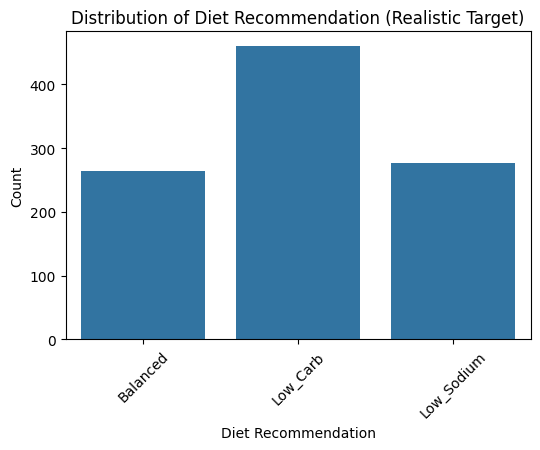

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Diet_Recommendation")

plt.title("Distribution of Diet Recommendation (Realistic Target)")
plt.xlabel("Diet Recommendation")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


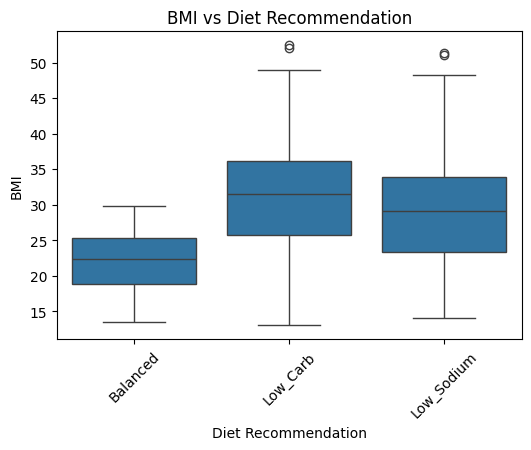

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Diet_Recommendation",
    y="BMI"
)

plt.title("BMI vs Diet Recommendation")
plt.xlabel("Diet Recommendation")
plt.ylabel("BMI")
plt.xticks(rotation=45)

plt.show()

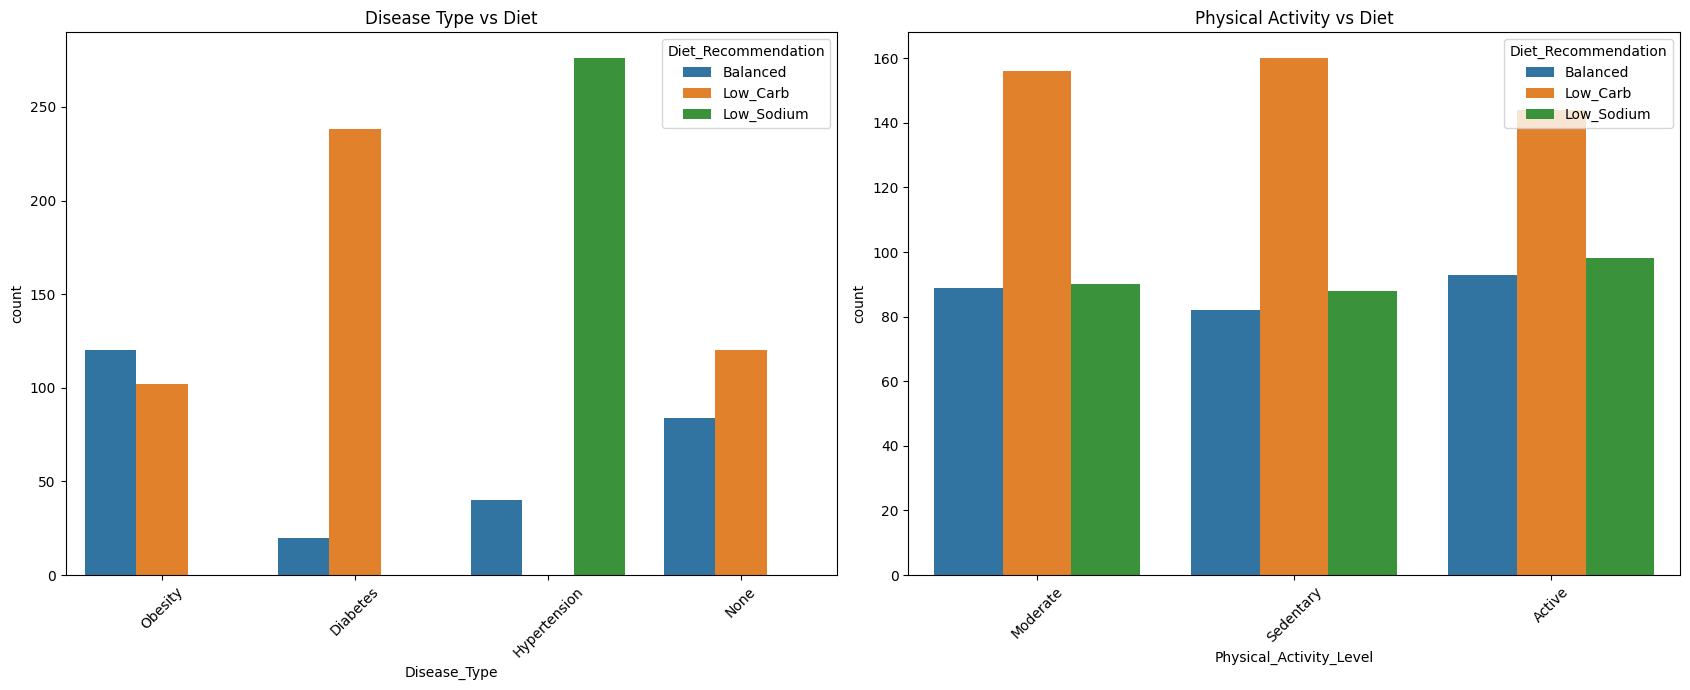

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(17,7))

# 1️⃣ Disease vs Diet
sns.countplot(
    data=df,
    x="Disease_Type",
    hue="Diet_Recommendation",
    ax=axes[0]
)
axes[0].set_title("Disease Type vs Diet")
axes[0].tick_params(axis='x', rotation=45)

# 2️⃣ Activity vs Diet
sns.countplot(
    data=df,
    x="Physical_Activity_Level",
    hue="Diet_Recommendation",
    ax=axes[1]
)
axes[1].set_title("Physical Activity vs Diet")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [40]:
# safe drop (agar future me columns list change ho jaye)
drop_cols_for_X = ["Diet_Recommendation", "Meal Plan"]
drop_cols_for_X = [c for c in drop_cols_for_X if c in df.columns]

X = df.drop(columns=drop_cols_for_X)
y = df["Diet_Recommendation"]

print("X columns:", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)

X columns: ['Age', 'Gender', 'BMI', 'Goal', 'Preferred_Cuisine', 'Allergies', 'Disease_Type', 'Severity', 'Physical_Activity_Level', 'Sleep_Hours', 'Budget_Level']
X shape: (1000, 11)
y shape: (1000,)


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (800, 11)
Test : (200, 11)


In [42]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: ['Gender', 'Goal', 'Preferred_Cuisine', 'Allergies', 'Disease_Type', 'Severity', 'Physical_Activity_Level', 'Budget_Level']
Numeric: ['Age', 'BMI', 'Sleep_Hours']


In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

In [45]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("rf", rf)
])

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [6, 7, 12],
    "rf__min_samples_split": [5, 10],
    "rf__min_samples_leaf": [2, 5],
    "rf__class_weight": [None, "balanced"]

}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=1
)


In [47]:
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'rf__class_weight': 'balanced', 'rf__max_depth': 7, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}
Best CV Accuracy: 0.9625


In [48]:
from sklearn.metrics import accuracy_score

best_model = grid_search.best_estimator_

train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy :", accuracy_score(y_test, test_pred))

Training Accuracy: 0.9975
Testing Accuracy : 0.965


In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

    Balanced       1.00      0.87      0.93        53
    Low_Carb       0.95      1.00      0.97        92
  Low_Sodium       0.96      1.00      0.98        55

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200



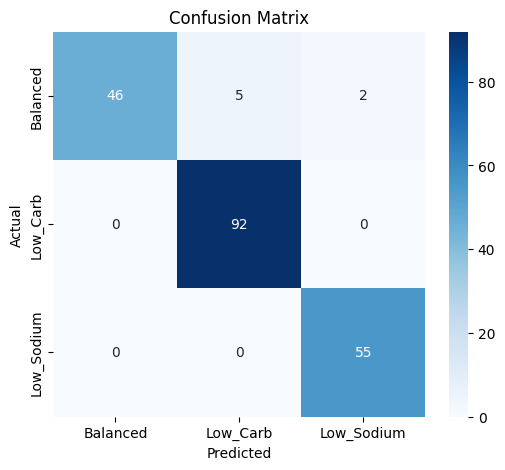

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_pred)
labels = sorted(y.unique())

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [51]:
# Trained best_model se preprocessing part nikaalo
preprocessor = best_model.named_steps["preprocess"]

# Entire dataset ko transform karo
X_processed = preprocessor.transform(X)

# Feature names nikaalo
feature_names = preprocessor.get_feature_names_out()

# DataFrame banao
import pandas as pd

X_encoded = pd.DataFrame(X_processed, columns=feature_names)

print("Encoded shape:", X_encoded.shape)

Encoded shape: (1000, 28)


In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sirf features (target aur meal plan hata do agar abhi bhi hain)
feature_df = df.drop(columns=["Diet_Recommendation", "Meal Plan"]).copy()

# Har categorical feature ko numeric codes me convert karo
for col in feature_df.select_dtypes(include="object").columns:
    feature_df[col] = feature_df[col].astype("category").cat.codes

print(feature_df.head())

   Age  Gender   BMI  Goal  Preferred_Cuisine  Allergies  Disease_Type  \
0   56       1  22.8     1                  3          2             3   
1   69       1  35.4     0                  0          2             0   
2   46       0  21.2     1                  0          2             1   
3   32       1  21.6     1                  3          1             2   
4   60       1  20.5     1                  2          1             0   

   Severity  Physical_Activity_Level  Sleep_Hours  Budget_Level  
0         1                        1            7             1  
1         0                        1            8             1  
2         0                        2            6             1  
3         0                        1            8             1  
4         1                        2            8             1  


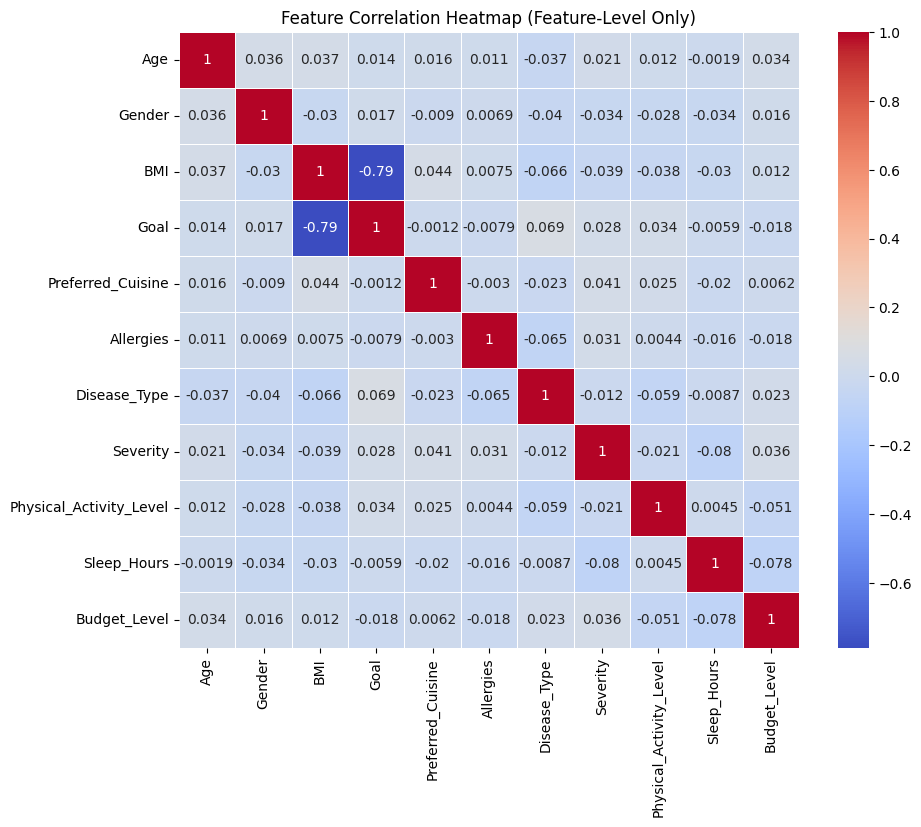

In [53]:
plt.figure(figsize=(10,8))

sns.heatmap(
    feature_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap (Feature-Level Only)")
plt.show()

In [54]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring="accuracy")

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


CV Scores: [0.97  0.925 0.99  0.96  0.98 ]
Mean CV Accuracy: 0.9649999999999999


In [55]:
import joblib

joblib.dump(best_model, "new_diet_model_realistic.pkl")
print("Model Saved Successfully")
import os
os.getcwd()

Model Saved Successfully


'C:\\Users\\syeda\\Downloads\\project'

In [56]:
# ====== Meal planning logic & helpers ======

def map_cuisine(pref: str) -> str:
    """Normalize user preferred cuisine into main groups."""
    if isinstance(pref, str):
        p = pref.strip().lower()
        if "italian" in p:
            return "Italian"
        if "mexican" in p:
            return "Mexican"
        if "chinese" in p:
            return "Chinese"
        if "pak" in p or "desi" in p:
            return "Pakistani"
    return "Pakistani"


# ---- Base meal plans (diet + budget + cuisine) ----

MEAL_PLANS_BASE = {
    # --------- PAKISTANI ---------
    ("Balanced", "Low", "Pakistani"): {
        "Breakfast": ["1 roti + daal", "chai without sugar"],
        "Lunch": ["daal + sabzi + 1 roti"],
        "Dinner": ["sabzi + salad"]
    },
    ("Balanced", "Medium", "Pakistani"): {
        "Breakfast": ["paratha (less oil) + omelette"],
        "Lunch": ["chicken curry + 1 roti + salad"],
        "Dinner": ["grilled chicken + vegetables"]
    },
    ("Balanced", "High", "Pakistani"): {
        "Breakfast": ["oats with milk and nuts"],
        "Lunch": ["grilled fish + brown rice + salad"],
        "Dinner": ["chicken steak + vegetables + soup"]
    },

    ("Low_Carb", "Low", "Pakistani"): {
        "Breakfast": ["2 boiled eggs + salad"],
        "Lunch": ["chicken + sabzi without roti"],
        "Dinner": ["daal + salad (no roti)"]
    },
    ("Low_Carb", "Medium", "Pakistani"): {
        "Breakfast": ["omelette + salad"],
        "Lunch": ["grilled chicken + mixed vegetables"],
        "Dinner": ["fish + salad"]
    },
    ("Low_Carb", "High", "Pakistani"): {
        "Breakfast": ["eggs + avocado + salad"],
        "Lunch": ["grilled salmon + vegetables"],
        "Dinner": ["chicken breast + broccoli"]
    },

    ("Low_Sodium", "Low", "Pakistani"): {
        "Breakfast": ["suji porridge (low salt) + banana"],
        "Lunch": ["boiled daal + rice (low salt)"],
        "Dinner": ["vegetable soup (low salt)"]
    },
    ("Low_Sodium", "Medium", "Pakistani"): {
        "Breakfast": ["oats with fruit (no added salt)"],
        "Lunch": ["grilled chicken (no extra salt) + vegetables"],
        "Dinner": ["lentil soup + salad (low salt)"]
    },
    ("Low_Sodium", "High", "Pakistani"): {
        "Breakfast": ["yogurt + fruit bowl (no salt)"],
        "Lunch": ["baked fish + mashed potatoes (low salt)"],
        "Dinner": ["chicken stew (low salt) + salad"]
    },

    # --------- ITALIAN ---------
    ("Balanced", "Low", "Italian"): {
        "Breakfast": ["plain toast + boiled egg"],
        "Lunch": ["simple tomato pasta (small portion)"],
        "Dinner": ["minestrone-style vegetable soup"]
    },
    ("Balanced", "Medium", "Italian"): {
        "Breakfast": ["scrambled eggs + toast"],
        "Lunch": ["grilled chicken pasta + salad"],
        "Dinner": ["margherita pizza slice + salad"]
    },
    ("Balanced", "High", "Italian"): {
        "Breakfast": ["yogurt + granola + fruit"],
        "Lunch": ["grilled salmon with olive oil + veggies"],
        "Dinner": ["chicken alfredo (light sauce) + salad"]
    },

    ("Low_Carb", "Low", "Italian"): {
        "Breakfast": ["omelette with tomatoes and cheese"],
        "Lunch": ["zucchini noodles with tomato sauce"],
        "Dinner": ["grilled chicken + sautéed vegetables"]
    },
    ("Low_Carb", "Medium", "Italian"): {
        "Breakfast": ["eggs + sautéed mushrooms"],
        "Lunch": ["chicken salad with olive oil dressing"],
        "Dinner": ["baked fish with herbs + vegetables"]
    },
    ("Low_Carb", "High", "Italian"): {
        "Breakfast": ["egg frittata with veggies"],
        "Lunch": ["grilled steak + salad"],
        "Dinner": ["salmon fillet + broccoli + olive oil"]
    },

    ("Low_Sodium", "Low", "Italian"): {
        "Breakfast": ["plain oats + fruit (no salt)"],
        "Lunch": ["pasta with no added salt sauce"],
        "Dinner": ["vegetable soup (no added salt)"]
    },
    ("Low_Sodium", "Medium", "Italian"): {
        "Breakfast": ["fruit salad + unsalted nuts"],
        "Lunch": ["grilled chicken (no salt) + veggies"],
        "Dinner": ["risotto with low-salt broth"]
    },
    ("Low_Sodium", "High", "Italian"): {
        "Breakfast": ["Greek yogurt + berries"],
        "Lunch": ["baked fish (no salt) + vegetables"],
        "Dinner": ["chicken with herbs + olive oil + salad"]
    },

    # --------- MEXICAN ---------
    ("Balanced", "Low", "Mexican"): {
        "Breakfast": ["scrambled eggs + tortilla"],
        "Lunch": ["beans + rice + salsa"],
        "Dinner": ["vegetable stew with tortilla"]
    },
    ("Balanced", "Medium", "Mexican"): {
        "Breakfast": ["egg burrito (light cheese)"],
        "Lunch": ["grilled chicken tacos + salad"],
        "Dinner": ["bean chili + brown rice"]
    },
    ("Balanced", "High", "Mexican"): {
        "Breakfast": ["yogurt parfait with fruit"],
        "Lunch": ["grilled fish tacos + salad"],
        "Dinner": ["chicken fajitas + veggies"]
    },

    ("Low_Carb", "Low", "Mexican"): {
        "Breakfast": ["eggs + salsa (no tortilla)"],
        "Lunch": ["chicken + vegetable bowl (no rice)"],
        "Dinner": ["bean + salad bowl"]
    },
    ("Low_Carb", "Medium", "Mexican"): {
        "Breakfast": ["omelette with peppers"],
        "Lunch": ["grilled chicken salad + salsa"],
        "Dinner": ["fish + veggies (no tortilla)"]
    },
    ("Low_Carb", "High", "Mexican"): {
        "Breakfast": ["eggs + avocado + salsa"],
        "Lunch": ["steak fajitas (no tortilla)"],
        "Dinner": ["grilled shrimp + veggies"]
    },

    ("Low_Sodium", "Low", "Mexican"): {
        "Breakfast": ["oats + fruit (no salt)"],
        "Lunch": ["beans + rice (low salt)"],
        "Dinner": ["vegetable soup (low salt)"]
    },
    ("Low_Sodium", "Medium", "Mexican"): {
        "Breakfast": ["fruit + unsalted nuts"],
        "Lunch": ["chicken bowl (low salt) + veggies"],
        "Dinner": ["bean chili (low salt) + salad"]
    },
    ("Low_Sodium", "High", "Mexican"): {
        "Breakfast": ["yogurt + fruit bowl"],
        "Lunch": ["baked fish (low salt) + veggies"],
        "Dinner": ["chicken stew (low salt) + salad"]
    },

    # --------- CHINESE ---------
    ("Balanced", "Low", "Chinese"): {
        "Breakfast": ["congee (rice porridge) + egg"],
        "Lunch": ["stir-fry veggies + small rice"],
        "Dinner": ["vegetable soup + rice"]
    },
    ("Balanced", "Medium", "Chinese"): {
        "Breakfast": ["boiled egg + steamed bun"],
        "Lunch": ["chicken stir-fry + rice"],
        "Dinner": ["noodle soup + vegetables"]
    },
    ("Balanced", "High", "Chinese"): {
        "Breakfast": ["yogurt + fruit"],
        "Lunch": ["grilled fish + stir-fry veggies"],
        "Dinner": ["chicken + broccoli + rice"]
    },

    ("Low_Carb", "Low", "Chinese"): {
        "Breakfast": ["egg drop soup"],
        "Lunch": ["chicken + broccoli (no rice)"],
        "Dinner": ["stir-fry veggies (no rice)"]
    },
    ("Low_Carb", "Medium", "Chinese"): {
        "Breakfast": ["boiled eggs + veggies"],
        "Lunch": ["beef + vegetables (no rice)"],
        "Dinner": ["fish + stir-fry veggies"]
    },
    ("Low_Carb", "High", "Chinese"): {
        "Breakfast": ["egg + tofu + veggies"],
        "Lunch": ["prawn stir-fry (no rice)"],
        "Dinner": ["chicken + mixed veggies (no rice)"]
    },

    ("Low_Sodium", "Low", "Chinese"): {
        "Breakfast": ["plain congee (no salt)"],
        "Lunch": ["vegetable stir-fry (low salt)"],
        "Dinner": ["veggie soup (low salt)"]
    },
    ("Low_Sodium", "Medium", "Chinese"): {
        "Breakfast": ["fruit + nuts (no salt)"],
        "Lunch": ["chicken stir-fry (low salt)"],
        "Dinner": ["rice + veggies (low salt)"]
    },
    ("Low_Sodium", "High", "Chinese"): {
        "Breakfast": ["yogurt + fruit"],
        "Lunch": ["baked fish (low salt) + veggies"],
        "Dinner": ["chicken + broccoli (low salt)"]
    },
}


# ---- Low sleep special Pakistani plans ----

MEAL_PLANS_LOW_SLEEP = {
    ("Balanced", "Low", "Pakistani"): {
        "Breakfast": ["milk + oats", "banana"],
        "Lunch": ["daal + chawal (light)"],
        "Dinner": ["vegetable soup + salad"]
    },
    ("Balanced", "Medium", "Pakistani"): {
        "Breakfast": ["milk + paratha (less oil)"],
        "Lunch": ["chicken curry (light spice) + roti"],
        "Dinner": ["khichdi + raita"]
    },
    ("Balanced", "High", "Pakistani"): {
        "Breakfast": ["yogurt + oats + nuts"],
        "Lunch": ["grilled fish + vegetables"],
        "Dinner": ["chicken soup + salad"]
    }
}








def get_plan_duration_days(disease, severity, bmi, goal):
    disease = str(disease).strip()
    severity = str(severity).strip()
    goal = str(goal).strip().lower()

    try:
        bmi = float(bmi)
    except:
        bmi = 25

    if disease == "Diabetes":
        if severity == "Severe":
            return 60
        elif severity == "Moderate":
            return 45
        else:
            return 30

    if disease == "Hypertension":
        if severity == "Severe":
            return 60
        elif severity == "Moderate":
            return 45
        else:
            return 30

    if disease == "Obesity":
        if bmi >= 30:
            return 90
        else:
            return 60

    if goal == "fat_burn":
        return 45

    return 30












def get_meal_plan(predicted_diet: str,
                  budget_level_raw,
                  preferred_cuisine_raw,
                  sleep_hours):
    """Diet + budget + cuisine + sleep_hours se final meal plan choose kare."""

    # --- normalize budget ---
    budget_level = str(budget_level_raw).strip().title()
    if budget_level not in ["Low", "Medium", "High"]:
        budget_level = "Medium"

    # --- cuisine group ---
    cuisine_group = map_cuisine(preferred_cuisine_raw)

    # --- sleep level ---
    try:
        h = float(sleep_hours)
    except Exception:
        h = 6
    if h < 5:
        sleep_level = "Low"
    elif h <= 7:
        sleep_level = "Medium"
    else:
        sleep_level = "High"

    key = (predicted_diet, budget_level, cuisine_group)

    # base plan
    meal_plan = MEAL_PLANS_BASE.get(key)

    # low sleep adjustment
    if sleep_level == "Low":
        low_sleep_plan = MEAL_PLANS_LOW_SLEEP.get(key)
        if low_sleep_plan is not None:
            meal_plan = low_sleep_plan

    # fallback
    if meal_plan is None:
        meal_plan = {
            "Breakfast": ["simple omelette + tea without sugar"],
            "Lunch": ["daal + 1 roti + salad"],
            "Dinner": ["sabzi + salad"]
        }

    debug_info = {
        "diet": predicted_diet,
        "budget_level": budget_level,
        "cuisine_group": cuisine_group,
        "sleep_level": sleep_level,
        "key": key
    }
    return meal_plan, debug_info


def predict_meals_for_user(user_input: dict):
    """User input dict se model + rules chala kar full meal plan print kare."""

    # 1) user input → DataFrame
    user_df = pd.DataFrame([user_input])

    # 2) make sure all model features present
    required_cols = X.columns.tolist()
    missing_cols = set(required_cols) - set(user_df.columns)

    for col in missing_cols:
        if col in df.select_dtypes(include=["object"]).columns:
            user_df[col] = df[col].mode()[0]
        else:
            user_df[col] = df[col].mean()

    user_df = user_df[required_cols]

    # 3) model se diet predict
    predicted_diet = best_model.predict(user_df)[0]
    











         # 3.1) plan duration calculate karo
    duration_days = get_plan_duration_days(
        user_input.get("Disease_Type", "None"),
        user_input.get("Severity", "Mild"),
        user_input.get("BMI", 25),
        user_input.get("Goal", "maintain")
    )

    
    
    
    
    
    
    
    
    
    
    
    # 4) meal plan rules
    budget_raw = user_input.get("Budget_Level", "Medium")
    cuisine_raw = user_input.get("Preferred_Cuisine", "Pakistani")
    sleep_hours = user_input.get("Sleep_Hours", 6)

    meal_plan, debug = get_meal_plan(
        predicted_diet,
        budget_raw,
        cuisine_raw,
        sleep_hours
    )

    # 5) nice print
    print("Predicted Diet Type:", debug["diet"])







    
    print("Plan Duration:", duration_days, "days")
    
    
    
    
    
    
    
    
    
    
    print("Budget Level (normalized):", debug["budget_level"])
    print("Preferred Cuisine (group):", debug["cuisine_group"])
    print("Sleep Level:", debug["sleep_level"])
    print("DEBUG key:", debug["key"])

    print("\nRecommended Meal Plan:")
    for meal, items in meal_plan.items():
        print(f"\n{meal}:")
        for it in items:
            print(" -", it)

    # return predicted_diet, meal_plan


    response = {
        "diet_type": debug["diet"],
        "plan_duration_days": duration_days,
        "breakfast": meal_plan.get("Breakfast", []),
        "lunch": meal_plan.get("Lunch", []),
        "dinner": meal_plan.get("Dinner", [])
    }

    return response

In [57]:
# ====== Test user – yahan sirf values change karni hain ======

test_user = {
    "Age": 30,
    "Gender": "Female",
    "BMI": 28,                        # ya Weight_kg + Height_cm bhi de sakti ho,
    "Goal": "fat_burn",
    "Preferred_Cuisine": "Mexican", # try: Italian / Mexican / Chinese
    "Allergies": "None",
    "Disease_Type": "Diabetes",
    "Severity": "Moderate",
    "Physical_Activity_Level": "Low",
    "Sleep_Hours": 6,                 # try: 4 vs 8
    "Budget_Level": "low"          # try: Low / Medium / High
}

# predict_meals_for_user(test_user)



result = predict_meals_for_user(test_user)
print("\nFinal Response Dictionary:")
print(result)

Predicted Diet Type: Low_Carb
Plan Duration: 45 days
Budget Level (normalized): Low
Preferred Cuisine (group): Mexican
Sleep Level: Medium
DEBUG key: ('Low_Carb', 'Low', 'Mexican')

Recommended Meal Plan:

Breakfast:
 - eggs + salsa (no tortilla)

Lunch:
 - chicken + vegetable bowl (no rice)

Dinner:
 - bean + salad bowl

Final Response Dictionary:
{'diet_type': 'Low_Carb', 'plan_duration_days': 45, 'breakfast': ['eggs + salsa (no tortilla)'], 'lunch': ['chicken + vegetable bowl (no rice)'], 'dinner': ['bean + salad bowl']}
